# Methodik und Mindestanforderungen der Bewertung


## Ziel, Gegenstand, Geltungsbereich
Vergleich ausgewählter Kommunikationsprotokolle (z. B. OPC UA, MQTT, REST-API/HTTPS, AMQP, Modbus/TCP, CoAP) für industrielle/IoT‑Anwendungen. Ergebnis ist ein 0–100‑Score und eine Rangfolge pro Protokoll. Die Darstellung der Ergebnisse und das Erstellen des Python Codes wurde mit Hilfe von KI erstellt (ist automatisch integriert in Virtual Studio Code). Die Funktionsweise wurde kritisch geprüft und die Darstellungen ebenfalls. Die Gewichtung und Bewertung sind auf Basis von der Ausarbeitung und Analyse der Quellen entstanden und wurden ohne KI in Erstbewertung geschätzt. Im Anschluss hat Chat GPT-5 die Bewertung nocheinmal Reflektiert!

## Kriterienkatalog und Skalenanker (1–5)
Für jedes Kriterium wird auf einer fünfstufigen Ordinalskala bewertet. Skalenanker definieren, was 1/3/5 bedeutet; 2 und 4 stehen für Zwischenstufen.

- Echtzeit/Latenz (echtzeit_latenz):
  - 5 = erfüllt strenge Echtzeitanforderungen/deterministisches Verhalten; Evidenz: Messung im Zielsetup oder verifizierte Benchmarks
  - 3 = geeignet für typische Near‑Realtime‑Anforderungen; Evidenz: Tests, Referenzimplementierungen
  - 1 = primär best‑effort, keine Echtzeitgarantien; Evidenz: Spezifikation/Architektur
- Interoperabilität/Standardisierung (interoperabilitaet_standardisierung):
  - 5 = etablierter, offen standardisierter Stack mit breiter Konformitätstestung
  - 3 = Standard vorhanden, teils proprietäre Erweiterungen
  - 1 = proprietär oder schwach standardisiert
- Skalierbarkeit (skalierbarkeit):
  - 5 = skaliert praxiserprobt auf große Knoten-/Nachrichtenmengen
  - 3 = mittlere Skalierung belegt
  - 1 = Skalierung eingeschränkt/nicht belegt
- Sicherheit (sicherheit):
  - 5 = aktuelle Kryptostandards, Härtungsleitfäden, Zertifizierungen verfügbar
  - 3 = gängige Sicherheitsmechanismen vorhanden, aber Einschränkungen
  - 1 = grundlegende Schwächen/fehlende Mechanismen
- Implementierung/Bibliotheken (implementierung_bibliotheken):
  - 5 = reife, wartbare Open‑Source/kommerziell verfügbare Stacks, breite Sprachauswahl
  - 3 = ausreichende Bibliotheken, teils Lücken
  - 1 = wenige/instabile Bibliotheken
- Kosten/Effizienz (kosten_effizienz):
  - 5 = geringe Gesamtbetriebskosten, effiziente Ressourcen/Messaging‑Overhead
  - 3 = moderat
  - 1 = hoch
- Zukunftssicherheit (zukunftssicherheit):
  - 5 = starke Roadmap, aktive Community/Industriekonsortien
  - 3 = moderate Weiterentwicklung
  - 1 = abnehmende Aktivität/Legacy
- Branchenverbreitung (branchenverbreitung):
  - 5 = weit verbreitet in relevanten Branchen/Use‑Cases
  - 3 = Nischen-/Teilverbreitung
  - 1 = geringe Verbreitung
- Hardware‑Unterstützung (hardware_unterstuetzung):
  - 5 = breite Unterstützung in Gateways/Devices, fertige Stacks auf Embedded‑Plattformen
  - 3 = selektiv
  - 1 = kaum

Hinweis: Skalenanker sind bewusst generisch gehalten; wo möglich können projektspezifische Schwellwerte ergänzt werden (z. B. Latenz < x ms).

## Bewertungsmaßstab und Rechenregel
Alle Kriterien werden auf 1–5 bewertet. Die Scores werden auf 0–100 normalisiert.

$$
\text{Score}_i = \frac{\sum_k w_k \cdot r_{i,k}}{5 \cdot \sum_k w_k} \cdot 100
$$

- r_{i,k} ∈ {1,2,3,4,5} ist die Bewertung von Option i auf Kriterium k
- w_k ≥ 0 ist das Gewicht von Kriterium k (Standard: w_k = 1; Gleichgewichtung)

## Datenbasis und Evidenz (Quellenpflicht)
Jede Einzelbewertung r_{i,k} wird mit mindestens einer Quelle oder Messbasis hinterlegt. Zulässige Evidenzarten:
- Norm/Spezifikation/Technische Richtlinie
- Hersteller‑/Konsortial‑Dokumentation oder Konformitätsprogramme
- Peer‑reviewte Publikation oder Industrie‑Whitepaper mit methodischer Transparenz
- Eigene Messung/Prototyp‑Test (Setup dokumentiert)

## Reproduzierbarkeit (Reliabilität light)
- Zweitbewertung für 20–30% der Items (anderer Bewerter). Maß: Prozent‑Übereinstimmung oder Cohen’s κ (optional). Abweichungen >1 Skalenpunkt werden begründet und ggf. korrigiert.

## Robustheitsprüfung (Gewichtungs‑Sensitivität)
- Vergleich der Rangfolge unter (a) gewählten Gewichten und (b) Gleichgewichtung. Änderung der Top‑Positionen dokumentieren.

## Entscheidungsregel
- Beispiel: MVP‑Schwelle bei Score ≥ 80 oder „Top‑1 mit stabiler Rangfolge in Robustheitsprüfung“.

## Grenzen/Annahmen
- Wo Messwerte fehlen, wird konservativ bewertet und als Annahme gekennzeichnet.
- Ergebnisse gelten im definierten Scope (Use‑Cases/Umgebung) und sind bei geänderter Annahmenlage zu aktualisieren.


# Skript Bewertung Industrieprotokolle

## Einleitung
Einfache, gewichtete Bewertung von Kommunikationsstandards (1=schlecht … 5=sehr gut).
Ausgabe: sortierte Tabelle; bestes Ergebnis wird hervorgehoben.

In [6]:
#import der notwendigen Tools
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

## Gewichtung
### Begründung der Gewichtung

Die Verteilung summiert sich zu 100 % und spiegelt eine Ausrichtung auf OT‑Sicherheit und operative Durchgängigkeit wider: In industriellen Systemen ist nicht die maximale Feature‑Dichte entscheidend, sondern verlässliche, sichere Datenflüsse mit geringer Latenz, breiter Geräteunterstützung und tragfähiger Zukunftsperspektive.

An erster Stelle steht die Sicherheit (14 %). In produktionsnahen Netzen sind Angriffsflächen, Fehlkonfigurationen und Altgeräte realistische Risiken; Authentifizierung, Verschlüsselung, Schlüsselverwaltung und Rechtekonzepte müssen tragfähig sein. Sicherheit hat Vorrang vor kurzfristigen Kostenvorteilen, da Ausfälle oder Manipulationen direkt in Qualitätsverlust, Stillstand oder Compliance‑Probleme münden.

Gleichrangig hoch (je 12 %) bewertet sind Echtzeit‑Latenz, Interoperabilität/Standardisierung, Skalierbarkeit und Hardware‑Unterstützung. Niedrige und vorhersagbare Latenzen sind für Taktzeiten und Reaktionspfade zentral; offene Standards und saubere Datenmodelle minimieren Herstellerbindung und Integrationsaufwand; Skalierbarkeit stellt sicher, dass vom Pilot bis zur Fläche keine Architekturbrüche entstehen; breite Hardware‑Unterstützung reduziert Projektrisiko, erleichtert Brownfield‑Anbindung und beschleunigt die Beschaffung.

Mit 10 % gewichtet sind Implementierung/Bibliotheken, Zukunftssicherheit und Branchenverbreitung. Gute SDKs, Referenzen und Tooling senken Implementierungsrisiken und Time‑to‑Value; Zukunftssicherheit (Roadmap, Kompatibilität mit modernen Transporten/Netzen) verhindert Sackgassen; die Verbreitung in der Branche ist ein Proxy für verfügbare Expertise und Best Practices, bleibt aber nachgeordnet gegenüber harter Technikqualität.

Kosten‑Effizienz erhält 8 %. Zwar sind Lizenz‑, Betriebs‑ und Integrationskosten relevant, doch in sicherheitskritischen, langfristig betriebenen OT‑Umgebungen überwiegen Robustheit, Sicherheit und Skalierbarkeit. Kosten fließen als Total‑Cost‑of‑Ownership über den Lebenszyklus ein, werden jedoch nicht zum Primärkriterium erhoben.

Praktisch bedeutet diese Aufteilung: Für Shopfloor‑nahe, latenzkritische Anwendungen sind Protokolle mit deterministischerem Verhalten, breiter Geräteunterstützung und starkem Sicherheitsmodell im Vorteil; in Cloud‑/Analytics‑Szenarien könnte die Gewichtung für Skalierbarkeit und Implementierungsfreundlichkeit moderat angehoben werden, ohne die Sicherheitspräferenz zu unterlaufen.


In [7]:
gewichte = {
    "echtzeit_latenz": 12,
    "interoperabilitaet_standardisierung": 12,
    "skalierbarkeit": 12,
    "sicherheit": 14,
    "implementierung_bibliotheken": 10,
    "kosten_effizienz": 8,
    "zukunftssicherheit": 10,
    "branchenverbreitung": 10,
    "hardware_unterstuetzung": 12,
    }

## Bewertung der Kriterien
Wichtiges Journal zur Bewertung: https://www.mdpi.com/1999-5903/11/3/66

Publikation: https://duepublico2.uni-due.de/receive/duepublico_mods_00047707

### Modbus/TCP
Modbus/TCP ist extrem einfach, weit verbreitet und günstig zu integrieren, weshalb Implementierungsaufwand und Kosten positiv ausfallen. Historisch fehlten jedoch native Authentifizierung und Verschlüsselung; das „Modbus/TCP Security“-Profil ergänzt genau dies über TLS 1.2+ und X.509‑Zertifikate inkl. Rollenmodellen. In OT‑Umgebungen empfiehlt NIST zusätzlich Netzwerksegmentierung und strikte Härtung, da Modbus oft in Brownfield‑Anlagen eingesetzt wird 

#### Quellen

https://www.modbus.org/file/secure/modbussecurityprotocol.pdf

https://www.mdpi.com/1999-5903/11/3/66

### OPC UA
OPC UA punktet mit standardisierten Datenmodellen und einem durchgängigen Sicherheitsmodell (Profile für Sign/Encrypt, PKI‑basierte Zertifikatsverwaltung, Schutz vor Replay). Mit PubSub (Part 14) kann UA sowohl skalierbare Cloud‑Transporte (MQTT/AMQP) nutzen als auch niedrige Latenzen über UDP/TSN erreichen, wodurch Interoperabilität, Sicherheit und Echtzeit in der Bewertung stark sind:

#### Quellen

https://opcfoundation.org/news/press-releases/opc-foundation-announces-opc-ua-pubsub-release-important-extension-opc-ua-communication-platform/

https://reference.opcfoundation.org/Core/Part14/v104/docs/5.1

https://reference.opcfoundation.org/Core/Part2/4.8/


### MQTT
MQTT ist ein leichtgewichtiges Publish/Subscribe‑Protokoll mit QoS‑Stufen, ideal für große Gerätezahlen und Cloud‑Anbindung. TLS und moderne Authentifizierungsverfahren sind gängige Praxis; harte Deterministik ist jedoch nicht Ziel des Designs. Deshalb hohe Bewertungen für Skalierbarkeit, Implementierung und Kosten, solide Sicherheit, aber nur mittlere Echtzeit:

#### Quellen

https://mqtt.org/

https://www.mdpi.com/1999-5903/11/3/66

### REST‑API (HTTPS)
REST über HTTPS ist universell, einfach und kostengünstig integrierbar; die Transportsicherheit über TLS 1.3 ist stark und mit geringerem Handshake‑Overhead als früheren TLS‑Versionen. Aufgrund der Request/Response‑Semantik und HTTP‑Overheads ist harte Echtzeit/Deterministik begrenzt, weshalb Latenz niedriger bewertet wird, Interoperabilität/Sicherheit dagegen gut:

#### Quellen

https://www.ietf.org/rfc/rfc9325.html

https://datatracker.ietf.org/doc/html/rfc8446

### AMQP
AMQP ist ein robustes, binäres Enterprise‑Messaging mit Routing/Transaktionen; Sicherheit ist über SASL und TLS („amqps“/Port 5671) normativ beschrieben. Es eignet sich für zuverlässige, gesicherte Broker‑Kommunikation und komplexe Messaging‑Topologien; Implementierungsaufwand und Shopfloor‑Hardware‑Präsenz sind typischerweise höher/geringer als bei MQTT, was die Bewertungen erklärt:

#### Quellen

https://docs.oasis-open.org/amqp/core/v1.0/cos01/amqp-core-security-v1.0-cos01.html

### CoAP
CoAP ist ein REST‑Protokoll für stark eingeschränkte IoT‑Geräte (UDP) mit sehr kleinem Footprint; Sicherheit lässt sich über DTLS („CoAPS“) oder OSCORE herstellen. In industriellen Anlagen ist die Verbreitung und Hardware‑Unterstützung meist geringer, Echtzeit ohne harte Deterministik; daher gute Effizienz, ordentliche Latenz, aber schwächere Adoption/Hardware‑Support

#### Quellen

https://datatracker.ietf.org/doc/html/rfc8323

https://www.rfc-editor.org/rfc/rfc8613.txt


Bewertungen (1=schlecht … 5=sehr gut)

In [8]:
bewertungen = {
    "Modbus/TCP": {
        "echtzeit_latenz": 2, "interoperabilitaet_standardisierung": 3, "skalierbarkeit": 2,
        "sicherheit": 1, "implementierung_bibliotheken": 5, "kosten_effizienz": 5,
        "zukunftssicherheit": 2, "branchenverbreitung": 5, "hardware_unterstuetzung": 5,
    },
    "OPC UA": {
        "echtzeit_latenz": 4, "interoperabilitaet_standardisierung": 5, "skalierbarkeit": 4,
        "sicherheit": 5, "implementierung_bibliotheken": 3, "kosten_effizienz": 4,
        "zukunftssicherheit": 5, "branchenverbreitung": 5, "hardware_unterstuetzung": 4,
    },
    "MQTT": {
        "echtzeit_latenz": 3, "interoperabilitaet_standardisierung": 3, "skalierbarkeit": 5,
        "sicherheit": 4, "implementierung_bibliotheken": 5, "kosten_effizienz": 5,
        "zukunftssicherheit": 4, "branchenverbreitung": 4, "hardware_unterstuetzung": 4,
    },
    "REST-API (HTTPS)": {
        "echtzeit_latenz": 2, "interoperabilitaet_standardisierung": 4, "skalierbarkeit": 4,
        "sicherheit": 4, "implementierung_bibliotheken": 4, "kosten_effizienz": 5,
        "zukunftssicherheit": 4, "branchenverbreitung": 3, "hardware_unterstuetzung": 3,
    },
    "AMQP": {
        "echtzeit_latenz": 3, "interoperabilitaet_standardisierung": 4, "skalierbarkeit": 4,
        "sicherheit": 4, "implementierung_bibliotheken": 3, "kosten_effizienz": 4,
        "zukunftssicherheit": 3, "branchenverbreitung": 3, "hardware_unterstuetzung": 2,
    },
    "CoAP": {
        "echtzeit_latenz": 3, "interoperabilitaet_standardisierung": 3, "skalierbarkeit": 4,
        "sicherheit": 3, "implementierung_bibliotheken": 3, "kosten_effizienz": 5,
        "zukunftssicherheit": 3, "branchenverbreitung": 2, "hardware_unterstuetzung": 2,
    },
}


## Reflexion der Bewertung mit unterstützung von KI (GPT5)

### Modbus/TCP
Einfach, günstig, überall verfügbar und daher 5 bei Implementierung/Kosten/Hardware/Verbreitung sind folgerichtig. Die 1 bei Sicherheit ist hart, aber vertretbar, wenn Du heutige Praxis ohne flächige Modbus‑Security annimmst. Interoperabilität 3 ist erklärbar, wenn „semantische“ Interop (Datenmodelle) mitbewertet wird; andernfalls könnte es auch 4 sein.

### OPC UA
Hohe Werte bei Interop (5), Sicherheit (5), Zukunft (5) und Verbreitung (5) passen exakt zur Begründung. Echtzeit 4 ist schlüssig, da PubSub/UDP/TSN stark ist, Client/Server moderat. Implementierung 3 und Kosten 4 sind realistisch.

### MQTT
Skalierbarkeit 5, Implementierung 5, Kosten 5 und Sicherheit 4 passen. Echtzeit 3 ist angemessen. Interoperabilität 3 ist konservativ; wenn Du „Standardisierung ohne Datenmodell“ bewertest, ist 3 ok—bei Fokus auf Ökosystem/Kompatibilität könnte 4 gerechtfertigt sein.

### REST‑API (HTTPS)
Gute Interop 4, Skalierbarkeit 4, Sicherheit 4 und Kosten 5 sind konsistent mit der Web‑/Cloud‑Praxis; Echtzeit 2 spiegelt das Request/Response‑Modell. Hardware‑Unterstützung 3 in OT ist plausibel.

### AMQP
Zuverlässiges Enterprise‑Messaging: Interop 4, Sicherheit 4, Skalierbarkeit 4 und Implementierung 3 passen. Zukunftssicherheit 3 ist defensiv; im Enterprise‑Kontext ließe sich 4 argumentieren, im Shopfloor‑OT eher 3.

### CoAP
Effizient für constrained Devices: Kosten 5, Skalierbarkeit 4, Echtzeit 3, Sicherheit 3 (ohne OSCORE flächig) und geringe Verbreitung/Hardware 2 sind folgerichtig. Mit starker OSCORE/DTLS‑Nutzung könnte Sicherheit auch 4 sein; Deine 3 spiegelt die Praxis gut.

Rang,Protokoll,echtzeit_latenz,interoperabilitaet_standardisierung,skalierbarkeit,sicherheit,implementierung_bibliotheken,kosten_effizienz,zukunftssicherheit,branchenverbreitung,hardware_unterstuetzung,Score %,Hinweis
1,OPC UA,4,5,4,5,3,4,5,5,4,87.20,★ MVP
2,MQTT,3,3,5,4,5,5,4,4,4,81.20,
3,REST-API (HTTPS),2,4,4,4,4,5,4,3,3,72.40,
4,AMQP,3,4,4,4,3,4,3,3,2,66.80,
5,Modbus/TCP,2,3,2,1,5,5,2,5,5,63.60,
6,CoAP,3,3,4,3,3,5,3,2,2,61.20,


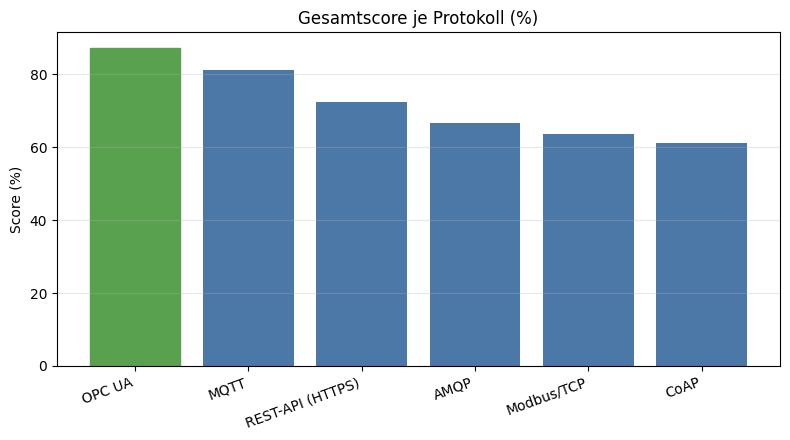

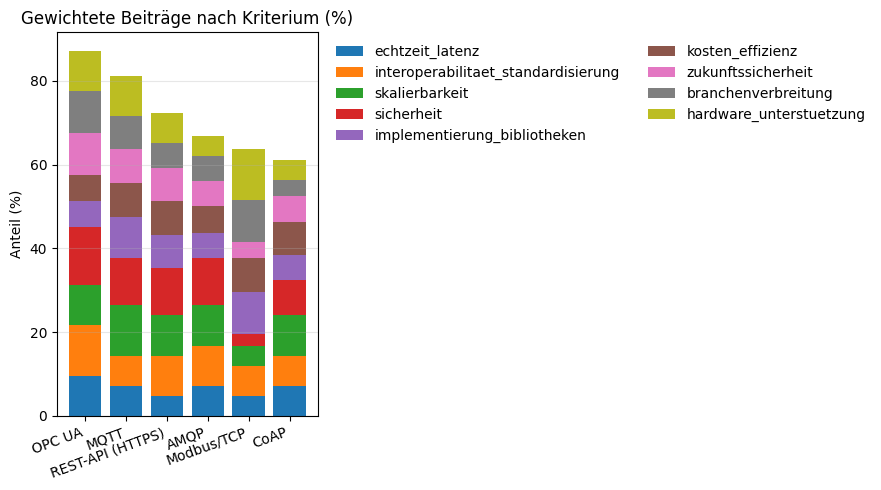

In [9]:
kriterien = list(gewichte.keys())
gewichte_norm = {k: v / sum(gewichte.values()) for k, v in gewichte.items()}

df_scores = pd.DataFrame.from_dict(bewertungen, orient="index")[kriterien]
score_gesamt = (df_scores * pd.Series(gewichte_norm)).sum(axis=1) / 5 * 100

df_tab = df_scores.copy()
df_tab["Score %"] = score_gesamt
df_tab = df_tab.sort_values("Score %", ascending=False)
df_tab.insert(0, "Protokoll", df_tab.index)
df_tab.insert(0, "Rang", range(1, len(df_tab) + 1))
df_tab["Hinweis"] = ""
df_tab.iloc[0, df_tab.columns.get_loc("Hinweis")] = "★ MVP"

best_index = df_tab.index[0]
styler = (
    df_tab.style
        .format({"Score %": "{:.2f}"})
        .apply(lambda row: ["background-color: #d8f5d0" if row.name == best_index else "" for _ in row], axis=1)
        .hide(axis="index")
)
display(styler)

plt.figure(figsize=(8, 4.5))
scores_sorted = df_tab.set_index("Protokoll")["Score %"]
bars = plt.bar(scores_sorted.index, scores_sorted.values, color="#4c78a8")
bars[0].set_color("#59a14f")  # Top grün
plt.title("Gesamtscore je Protokoll (%)")
plt.ylabel("Score (%)")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

beitraege = df_scores.mul(pd.Series(gewichte_norm), axis=1) / 5 * 100
beitraege = beitraege.loc[df_tab["Protokoll"]]  # gleiche Reihenfolge wie Tabelle
plt.figure(figsize=(9, 5))
bottom = None
colors = plt.get_cmap("tab10").colors
for i, k in enumerate(kriterien):
    vals = beitraege[k].values
    plt.bar(beitraege.index, vals, bottom=bottom, label=k, color=colors[i % len(colors)])
    bottom = vals if bottom is None else bottom + vals
plt.title("Gewichtete Beiträge nach Kriterium (%)")
plt.ylabel("Anteil (%)")
plt.xticks(rotation=20, ha="right")
plt.legend(ncol=2, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()